In [44]:
import numpy as np
import matplotlib.pyplot as plt
import random
import scipy.io
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from scipy.optimize import nnls
import sys      


In [3]:
plt.ioff()
wavelengths = np.linspace(1550, 1565, 1500)

In [4]:
def generate_sparse_spectrum(number_of_spikes):
    x = np.arange(1500)
    spectrum = np.zeros(1500)
    for _ in range(number_of_spikes):
        center = random.uniform(0, 1500)
        width = random.uniform(0.5, 2.0)
        intensity = random.random()
        spectrum += intensity * np.exp(-((x - center)**2) / (2 * width**2))
    return spectrum / np.max(spectrum)

def generate_narrow_absorption(number_of_spikes):
    x = np.arange(1500)
    spectrum = np.ones(1500)
    for _ in range(number_of_spikes):
        center = random.uniform(0, 1500)
        width = random.uniform(0.5, 2.0)
        intensity = random.random()
        spectrum -= intensity * np.exp(-((x - center)**2) / (2 * width**2))
    return np.clip(spectrum, 0, 1)

def broad_curve(x, x0, gamma, I_peak):
    return I_peak / (1 + ((x - x0) / gamma) ** 2)

def generate_broad_emission(number_of_peaks):
    spectrum = np.zeros(1500)
    spectrum_clean = np.arange(1500)
    for _ in range(number_of_peaks):
        center = random.uniform(0,1500)
        width = random.uniform(5,700)
        height = random.uniform(0.1,1.0)
        spectrum += broad_curve(spectrum_clean, center, width, height)
    return spectrum / np.max(spectrum)

def generate_broad_absorption(number_of_peaks):
    return 1.0 - generate_broad_emission(number_of_peaks)


In [ ]:

# Load Matrices
calibration_matrix = scipy.io.loadmat("/Users/jatinvirmatharoo/Documents/Spectrometer URA/transmission_matrices/Matrix_calabration_Dis7.mat")['mat2']

def simulate_measurement(spectrum, T, snr_db=30):
    measurement = np.dot(T, spectrum)
    signal_power = np.mean(measurement ** 2)
    noise_level = signal_power / (10 ** (snr_db / 10))
    noise = np.random.normal(0, np.sqrt(noise_level), measurement.shape)
    return measurement + noise

random.seed(42)
np.random.seed(42)
print("Generating 3000 synthetic samples...")
X_train_list, y_train_list = [], []
labels_list = []

for _ in range(3000):
    spectrum_generator = random.choice([
        generate_sparse_spectrum, generate_broad_emission,
        generate_narrow_absorption, generate_broad_absorption
    ])
    labels_list.append(spectrum_generator.__name__)
    spectrum = spectrum_generator(random.randint(1,10))
    snr_db = random.choice([30, 40, 50])
    measurement = simulate_measurement(spectrum, calibration_matrix, snr_db)

    X_train_list.append(measurement)
    y_train_list.append(spectrum)

# X holds spectrums + noise
X_train_np = np.array(X_train_list)
# y holds just the true spectrum itself
y_train_np = np.array(y_train_list)

print("Running Reg NNLS + L1 to generate rough drafts...")
print(labels_list[2])



Generating 3000 synthetic samples...
Running Reg NNLS + L1 to generate rough drafts...
generate_broad_emission


In [ ]:
# # the difference operator
# # want it to be smooth, and rough line
# # means adjacent indices have huge absolute jumps
# # this is matrix of -1 and 1 on diagonal, so $(x_{i+1} - x_i)$
# # so dont solve Tx = y, optimize it via Ridge Regression, and want x >= 0
# # $$\min_{x \ge 0} \left( ||Tx - y||_2^2 + \alpha ||Lx||_2^2 \right)$$
# # \alpha ||Lx||_2^2 \right)$$ smoothness, penalize big jumps, alpha is how much we care about this
# # this good for broad, for sparse, it spreads out large penalities
def build_L(n):
    L = np.zeros((n-1, n))
    for i in range(n-1):
        L[i, i] = -1
        L[i, i+1] = 1
    return L

# # 5000000 means we care a lot
# alpha = 5000000.0
alpha = 50000
T = calibration_matrix
L = build_L(1500)
# # T = [T, a*L]^t, y = [y 0]^t
T_aug = np.vstack([T, np.sqrt(alpha) * L])

X_train_rough = []
for i in range(3000):
    if i % 1 == 0:
        print(f"{i}/3000 done...")
    y_aug = np.concatenate([X_train_np[i], np.zeros(1499)])
    x, _ = nnls(T_aug, y_aug)
    x = np.clip(x, 0, 1)
    X_train_rough.append(x)

# # X_train_rough will now hold the noisy spectrum after reg nnls
X_train_rough = np.array(X_train_rough)

# # X_train_rough = X_rough_guess.detach().cpu().numpy()


0/5 done...
1/5 done...
2/5 done...
3/5 done...
4/5 done...
5/5 done...
6/5 done...
7/5 done...
8/5 done...
9/5 done...
10/5 done...
11/5 done...
12/5 done...
13/5 done...
14/5 done...
15/5 done...
16/5 done...
17/5 done...
18/5 done...
19/5 done...
20/5 done...
21/5 done...
22/5 done...
23/5 done...
24/5 done...
25/5 done...
26/5 done...
27/5 done...
28/5 done...
29/5 done...
30/5 done...
31/5 done...
32/5 done...
33/5 done...
34/5 done...
35/5 done...
36/5 done...
37/5 done...
38/5 done...
39/5 done...
40/5 done...
41/5 done...
42/5 done...
43/5 done...
44/5 done...
45/5 done...
46/5 done...
47/5 done...
48/5 done...
49/5 done...
50/5 done...
51/5 done...
52/5 done...
53/5 done...
54/5 done...
55/5 done...
56/5 done...
57/5 done...
58/5 done...
59/5 done...
60/5 done...
61/5 done...
62/5 done...
63/5 done...
64/5 done...
65/5 done...
66/5 done...
67/5 done...
68/5 done...
69/5 done...
70/5 done...
71/5 done...
72/5 done...
73/5 done...
74/5 done...
75/5 done...
76/5 done...
77/5 done

In [14]:
print(labels_list)

['generate_sparse_spectrum', 'generate_sparse_spectrum', 'generate_broad_emission', 'generate_broad_absorption', 'generate_broad_absorption', 'generate_broad_emission', 'generate_narrow_absorption', 'generate_sparse_spectrum', 'generate_broad_emission', 'generate_sparse_spectrum', 'generate_broad_absorption', 'generate_sparse_spectrum', 'generate_sparse_spectrum', 'generate_narrow_absorption', 'generate_sparse_spectrum', 'generate_broad_emission', 'generate_broad_emission', 'generate_narrow_absorption', 'generate_narrow_absorption', 'generate_narrow_absorption', 'generate_broad_absorption', 'generate_broad_absorption', 'generate_narrow_absorption', 'generate_broad_absorption', 'generate_broad_emission', 'generate_broad_absorption', 'generate_broad_emission', 'generate_narrow_absorption', 'generate_sparse_spectrum', 'generate_narrow_absorption', 'generate_narrow_absorption', 'generate_broad_emission', 'generate_sparse_spectrum', 'generate_broad_absorption', 'generate_broad_emission', 'g

In [ ]:
# np.save('data/X_train_rough.npy', X_train_rough)
# np.save('data/X_train_np.npy', X_train_np)
# np.save('data/y_train_np.npy', y_train_np)
# np.save('data/labels_list.npy', np.array(labels_list))



In [ ]:
X_train_rough = np.load('data/X_train_rough.npy')
X_train_np = np.load('data/X_train_np.npy')
y_train_np = np.load('data/y_train_np.npy')
labels_list = np.load('data/labels_list.npy', allow_pickle=True)


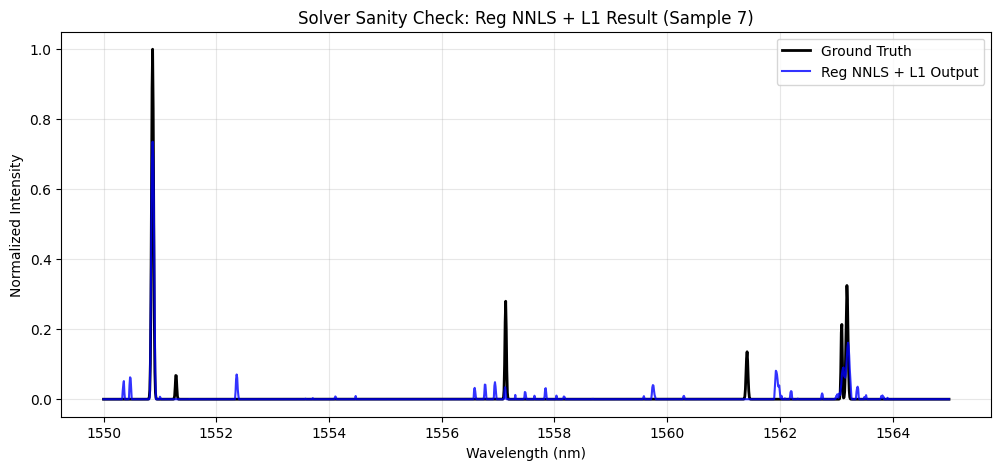

In [ ]:
# plot one graph to see
sample_idx = 7
plt.figure(figsize=(12, 5))
plt.plot(wavelengths, y_train_np[sample_idx], label="Ground Truth", color="black", linewidth=2)
plt.plot(wavelengths, X_train_rough[sample_idx], label="Reg NNLS + L1 Output", color="blue", alpha=0.8)
plt.title(f"Solver Sanity Check: Reg NNLS + L1 Result (Sample {sample_idx})")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Normalized Intensity")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show(block=True)



In [45]:
# Neural Network #1 to denoise and predict better

# now build neural network to clear up this rough mess, MLP
# need to experiemnt with different node sizes
# we have 25, they had 108
# Input: 1500 nodes
# Layer 1 : 32 nodes
# Layer 2 : 32 nodes
# OutputL 1500 nodes

# fully connected multi layer perceptron

class SolverNetwork(nn.Module):
  def __init__(self):
    super().__init__()
    # define layers

    self.layer1 = nn.Linear(1500, 2000)
    self.layer2 = nn.Linear(2000, 2000)
    self.layer3 = nn.Linear(2000, 1500)

    # activation function
    self.SiLU = nn.SiLU()

  def forward(self, x):
    x = self.layer1(x)
    x = self.SiLU(x)

    x = self.layer2(x)
    x = self.SiLU(x)

    x = self.layer3(x)

    return x


In [46]:
# Generate PyTorch Dataset

class SolverDataset(Dataset):
  def __init__(self, X, y, labels):
    self.X = torch.tensor(X, dtype= torch.float32)
    self.y = torch.tensor(y, dtype= torch.float32)
    self.labels = labels

  # used to know when one epoch is done
  def __len__(self):
    return len(self.X)

  def __getitem__(self, idx):
    return self.X[idx], self.y[idx], self.labels[idx]


In [47]:
# create training and validation set

split = int(0.8 * len(X_train_rough))
X_train = X_train_rough[:split]
X_val = X_train_rough[split:]
y_train = y_train_np[:split]
y_val = y_train_np[split:]
labels_train = labels_list[:split]
labels_val = labels_list[split:]

train_dataset = SolverDataset(X_train, y_train, labels_train)
val_dataset = SolverDataset(X_val, y_val, labels_val)



In [48]:
# load the data

batch_size = 50
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)


In [60]:
model = SolverNetwork()
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# higher = smoother
smoothness_lambda = 0.5

def combined_loss(predictions, targets):
    mse = loss_function(predictions, targets)
    smoothness = torch.mean((predictions[:, 1:] - predictions[:, :-1]) ** 2)
    return mse + smoothness_lambda + smoothness


In [61]:
epochs = 30
label_names = ['generate_sparse_spectrum', 'generate_narrow_absorption', 'generate_broad_emission', 'generate_broad_absorption']
for epoch in range(epochs):

  train_loss = 0.0
  model.train()
  for batch in train_loader:
    x = batch[0]
    y = batch[1]

    predictions = model(x)
    loss = combined_loss(predictions, y)

    optimizer.zero_grad()

    loss.backward()
    optimizer.step()

    train_loss += loss.item()

  model.eval()
  with torch.no_grad():
    val_loss = 0.0
    per_type_loss = {name: [] for name in label_names}
    for i, batch in enumerate(val_loader):
      x = batch[0]
      y = batch[1]
      labels_batch = batch[2]

      predictions = model(x)
      loss = combined_loss(predictions, y) 

      val_loss += loss.item()

      sample_losses = ((predictions - y) **2).mean(dim = 1)
      for j, lbl in enumerate(labels_batch):
        per_type_loss[lbl].append(sample_losses[j].item())



  
  avg_loss = train_loss / len(train_loader)

  print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_loss}, Val Loss: {val_loss/len(val_loader)}")
  for name in label_names:
        losses = per_type_loss[name]
        if losses:
            print(f"  {name.replace('generate_', '')}: {np.mean(losses):.6f}")






Epoch 1/30, Train Loss: 0.5939901731908321, Val Loss: 0.5333362619082133
  sparse_spectrum: 0.004598
  narrow_absorption: 0.017140
  broad_emission: 0.065563
  broad_absorption: 0.043344
Epoch 2/30, Train Loss: 0.5287207464377085, Val Loss: 0.518629401922226
  sparse_spectrum: 0.004490
  narrow_absorption: 0.022465
  broad_emission: 0.026934
  broad_absorption: 0.018017
Epoch 3/30, Train Loss: 0.5173441221316656, Val Loss: 0.5179926504691442
  sparse_spectrum: 0.004290
  narrow_absorption: 0.011208
  broad_emission: 0.029702
  broad_absorption: 0.022859
Epoch 4/30, Train Loss: 0.5155183772246043, Val Loss: 0.5131441255410513
  sparse_spectrum: 0.004150
  narrow_absorption: 0.012392
  broad_emission: 0.020003
  broad_absorption: 0.014271
Epoch 5/30, Train Loss: 0.5128778678675493, Val Loss: 0.5138506790002187
  sparse_spectrum: 0.004123
  narrow_absorption: 0.011750
  broad_emission: 0.024407
  broad_absorption: 0.013994
Epoch 6/30, Train Loss: 0.5113812312483788, Val Loss: 0.5119877258

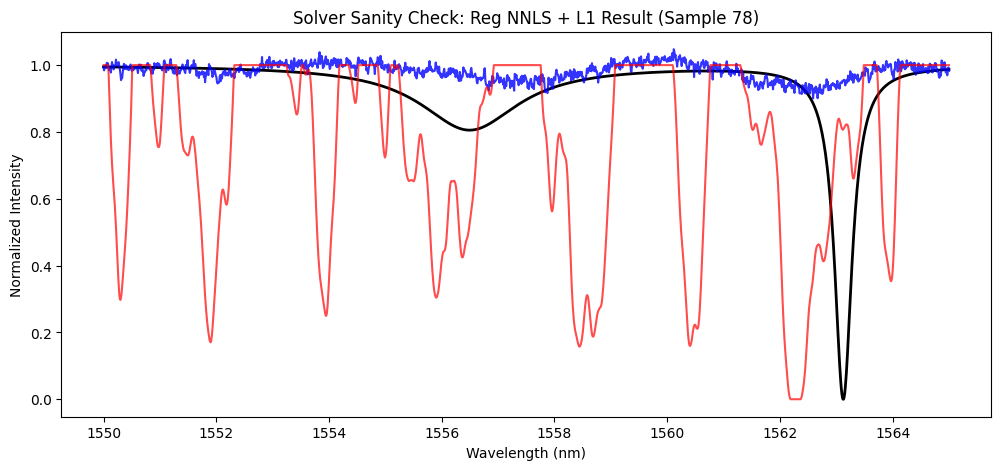

In [62]:
# compare one

sample_idx = 78
val_x = X_val[sample_idx]
val_t = y_val[sample_idx]

val_x = torch.tensor(val_x, dtype=torch.float32)
val_t = torch.tensor(val_t, dtype=torch.float32)

val_x = val_x.unsqueeze(0)
val_t = val_t.unsqueeze(0)

model.eval()

with torch.no_grad():
  val_pred = model(val_x)
  val_pred = val_pred.squeeze(0).numpy()
  val_t = val_t.squeeze(0).numpy()

  plt.figure(figsize=(12, 5))

  plt.plot(wavelengths, val_t, label="Ground Truth", color="black", linewidth=2)
  plt.plot(wavelengths, val_pred, label="Reg NNLS + L1 Output", color="blue", alpha=0.8)
  plt.plot(wavelengths, X_val[sample_idx], label="Solver output", color="red", alpha=0.7)
  plt.title(f"Solver Sanity Check: Reg NNLS + L1 Result (Sample {sample_idx})")
  plt.xlabel("Wavelength (nm)")
  plt.ylabel("Normalized Intensity")
  plt.show()


